In [34]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import f_classif
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from tqdm import tqdm
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import os
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import numpy as np
import shap
from sklearn.preprocessing import LabelEncoder



In [35]:
df_combined = pd.read_csv('data/All_features_all_tumours_with_metadata.csv')
df_combined

,PatientName,FO 10Percentile,FO 90Percentile,FO Energy,FO Entropy,FO InterquartileRange,FO Kurtosis,FO Maximum,FO MeanAbsoluteDeviation,FO Mean,...,GLSZM ZoneVariance,NGTDM Busyness,NGTDM Coarseness,NGTDM Complexity,NGTDM Contrast,NGTDM Strength,Model,GLbins,Wavelength,Reconstruction
0,10,69.142880,290.878683,1.925446e+06,-211066.055663,99.644165,23.988499,1506.465942,80.712806,167.184233,...,0.005226,141.041268,7.021165e+05,5.431388,-0.008386,-1.346671e+15,basal,8,700,BP
1,10,68.959734,246.576346,1.913616e+06,-213433.597164,80.613131,24.513340,1244.968140,64.953736,148.365253,...,0.003608,137.561953,6.350452e+05,5.512007,-0.008424,-1.347603e+15,basal,8,730,BP
2,10,70.308770,265.578290,1.918571e+06,-214352.172688,87.411236,24.715534,1360.987915,71.373395,156.751060,...,0.005046,140.418469,7.751153e+05,5.212363,-0.008415,-1.346064e+15,basal,8,750,BP
3,10,69.735306,273.831262,1.920929e+06,-210314.678012,91.426805,24.677900,1426.273926,74.664145,160.247312,...,0.003304,141.307182,5.620439e+05,5.830865,-0.008369,-1.347809e+15,basal,8,760,BP
4,10,68.767374,252.913724,1.915210e+06,-210869.408803,83.389416,24.597626,1282.152344,67.249362,150.974229,...,0.003673,140.365238,6.884752e+05,5.429985,-0.008394,-1.346774e+15,basal,8,770,BP
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,98,992.082990,4457.898047,9.779358e+06,314845.586861,1563.086426,9.743394,18382.693359,1110.867556,2444.303064,...,0.000031,96.333320,9.712949e+05,82287.526364,-0.001564,1.369483e+16,basal,256,770,MB
2264,98,851.154541,4067.293140,8.219187e+06,347907.061977,1421.651093,7.998629,14729.750000,1009.281441,2205.240598,...,0.000031,96.332213,1.128664e+06,105620.991383,0.000838,1.634342e+16,basal,256,800,MB
2265,98,838.989789,4029.269922,8.086392e+06,353231.076936,1419.266876,7.754886,14415.465820,1001.488346,2183.198058,...,0.000031,96.335268,1.169228e+06,104233.632403,0.001966,1.582569e+16,basal,256,820,MB
2266,98,878.749854,4083.819263,8.325601e+06,363272.297324,1443.129120,7.466826,13780.784180,1010.279500,2232.959583,...,0.000031,96.333182,1.179483e+06,110186.114695,0.003280,1.493451e+16,basal,256,840,MB


## Feautre Selection

### KW Test

In [36]:
# Define numeric features
feature_cols = df_combined.drop(columns=["PatientName", "Model", "Wavelength", "GLbins", "Reconstruction"]).select_dtypes("number").columns
target_col = "Model"

pvals = []
for col in feature_cols:
    groups = [group[col].values for _, group in df_combined.groupby(target_col)]
    _, p = kruskal(*groups)
    pvals.append(p)

# BH correction
reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.25, method='fdr_bh')

# Assemble results
kw_df = pd.DataFrame({
    "Feature": feature_cols,
    "p_value": pvals,
    "p_adj": pvals_corrected,
    "Keep": reject
}).set_index("Feature")

selected_features_kw = kw_df[kw_df["Keep"]].index.tolist()
print(f"✅ {len(selected_features_kw)} features selected after BH correction (FDR < 0.25)")

✅ 69 features selected after BH correction (FDR < 0.25)


### Correlation Filtering

In [37]:
import pingouin as pg
import pandas as pd

# Setup
df_selected = df_combined[["PatientName", "Model"] + selected_features_kw].copy()
scores = {f: 1 - kw_df.loc[f, "p_adj"] for f in selected_features_kw}

selected_features = set(selected_features_kw)
dropped_features = set()

for i, key1 in enumerate(selected_features_kw):
    for key2 in selected_features_kw[i + 1:]:
        if key1 in dropped_features or key2 in dropped_features:
            continue

        try:
            result = pg.rm_corr(data=df_selected, x=key1, y=key2, subject="PatientName")
            r = result["r"].values[0]

            if r > 0.9:
                score1 = scores.get(key1, 0)
                score2 = scores.get(key2, 0)

                if score2 > score1:
                    dropped_features.add(key1)
                elif score1 > score2:
                    dropped_features.add(key2)
                else:
                    # Tie: drop second one arbitrarily
                    dropped_features.add(key2)

        except Exception as e:
            print(f"⚠️ Failed correlation between {key1} and {key2}: {e}")

# Final selection
final_features = list(selected_features - dropped_features)
print(f"✅ {len(final_features)} features selected after rm_corr filtering")

# Optional: keep only final features in dataframe
df_final = df_combined[["PatientName", "Model"] + final_features]


/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covariance of constraints does not have full '
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-pac

✅ 34 features selected after rm_corr filtering


### Final Selected Radiomic Features (X)

## Classification

In [38]:
# Inputs
X = df_combined[final_features]
y = df_combined["Model"]

# Use stratified 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Classifier setup
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM (RBF kernel)": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42))
}

# Run CV
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
    print(f"✅ {name}: {scores.mean():.3f} ± {scores.std():.3f}")


✅ Random Forest: 1.000 ± 0.000
✅ Gradient Boosting: 1.000 ± 0.000
✅ SVM (RBF kernel): 0.980 ± 0.007


### SHAP (Model Interpretation)

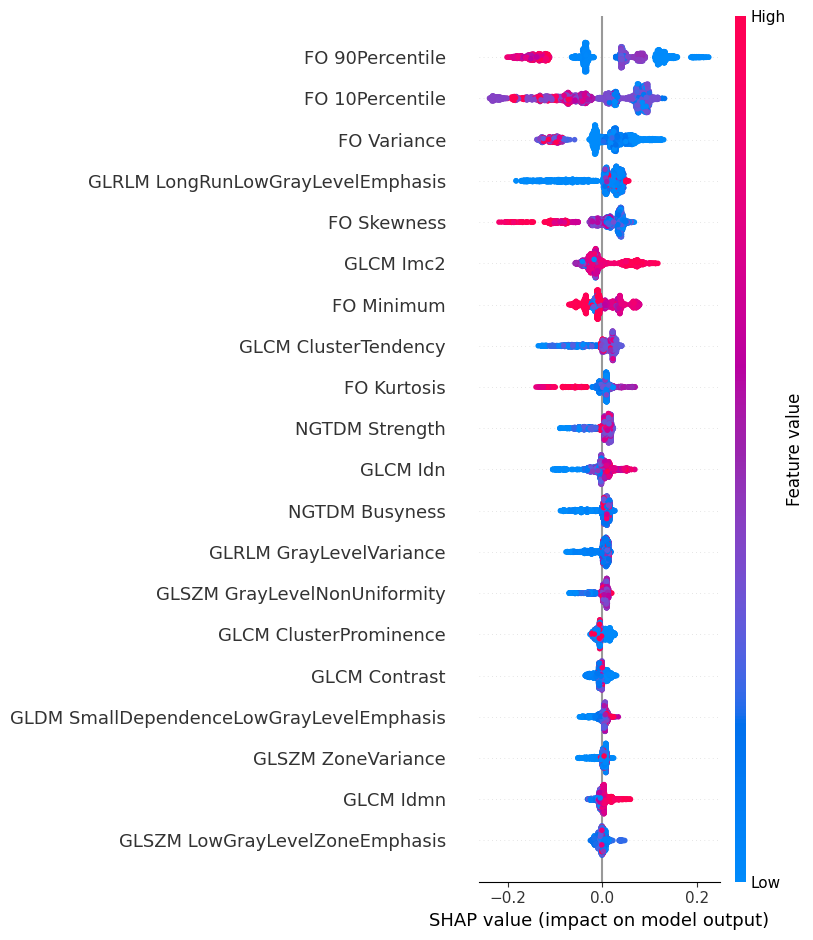

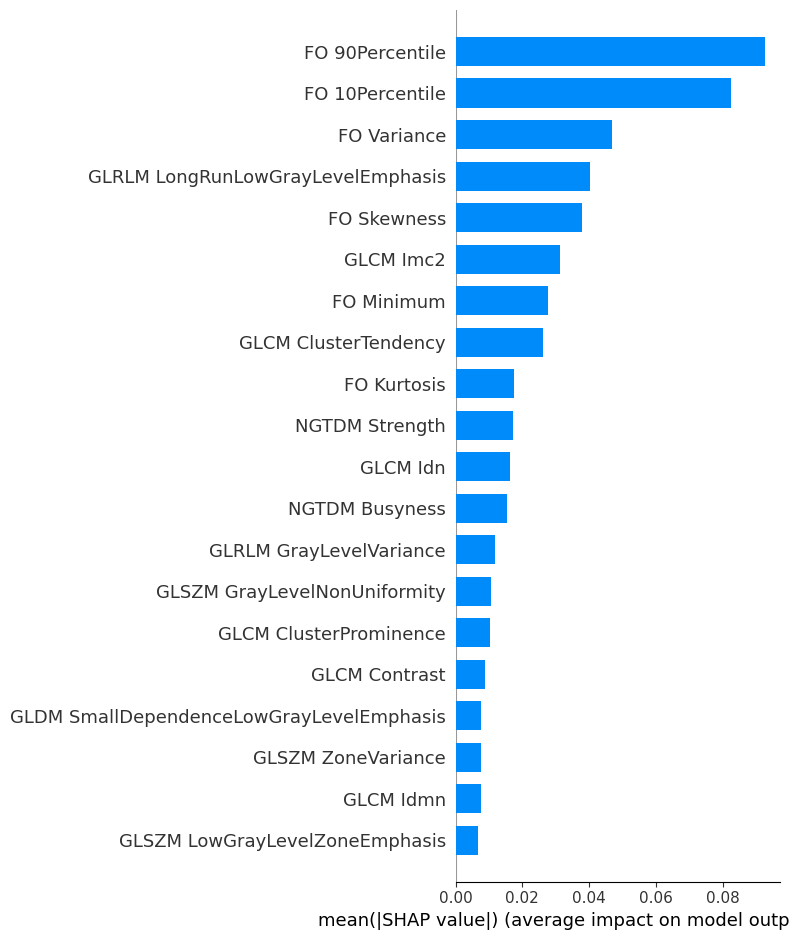

In [ ]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # e.g. basal=0, luminal=1

# Fit a model (e.g. Random Forest)
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y_encoded)

# Compute SHAP values
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)

# Plot summary for class 1 (e.g. luminal)
shap_values_class1 = shap_values[:, :, 1]

shap.summary_plot(shap_values_class1, X, feature_names=X.columns)
shap.summary_plot(shap_values_class1, X, feature_names=X.columns, plot_type="bar")


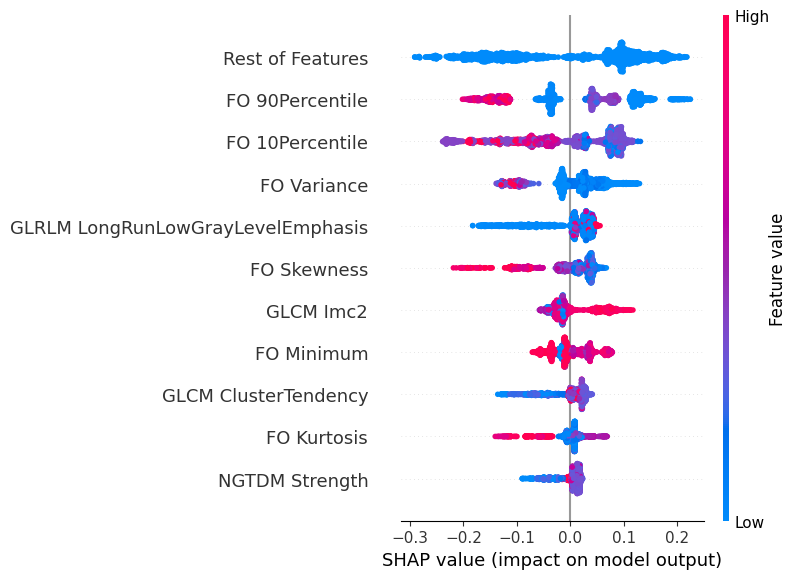

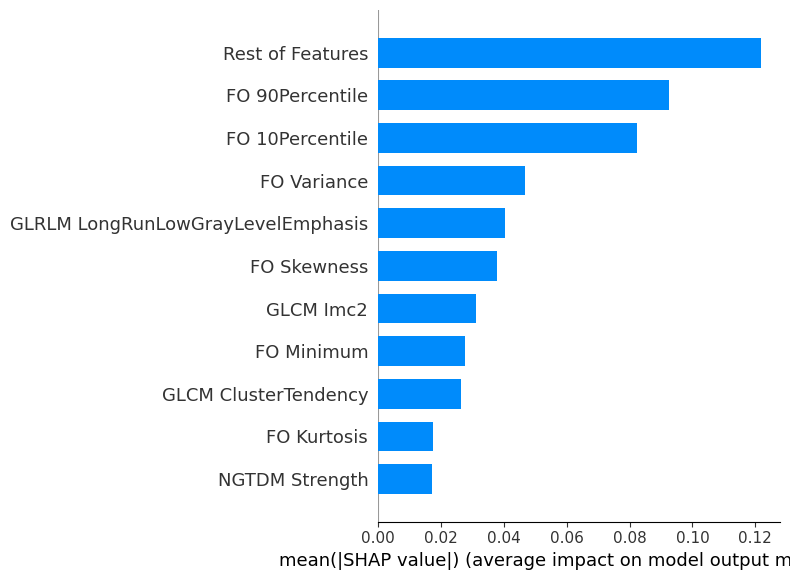

In [27]:
import numpy as np
import pandas as pd
import shap

# SHAP values for class 1 (e.g. luminal)
shap_values_class1 = shap_values[:, :, 1]  # shape (n_samples, n_features)

# Mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values_class1).mean(axis=0)

# Top 10 feature indices (sorted descending)
top_n = 10
top_indices = np.argsort(mean_abs_shap)[-top_n:][::-1]
top_features = X.columns[top_indices]

# Remaining feature indices for "Others"
other_indices = [i for i in range(X.shape[1]) if i not in top_indices]

# SHAP values for "Others" = sum across remaining features
shap_others = shap_values_class1[:, other_indices].sum(axis=1).reshape(-1, 1)

# SHAP values for top features
shap_top = shap_values_class1[:, top_indices]

# Combine SHAP values: top + others
shap_combined = np.hstack([shap_top, shap_others])

# Combine feature values (others has no values, just 0s for plotting color scale)
X_top = X.iloc[:, top_indices]
X_others = pd.DataFrame({"Rest of Features": np.zeros_like(shap_others[:, 0])})
X_combined = pd.concat([X_top, X_others], axis=1)

# Force correct column names
X_combined.columns = list(top_features) + ["Rest of Features"]

# Beeswarm plot (dot) with "Others" at the bottom
shap.summary_plot(shap_combined, X_combined, plot_type="dot", feature_names=X_combined.columns.tolist())

# Bar plot with "Others" at the bottom
shap.summary_plot(shap_combined, X_combined, plot_type="bar", feature_names=X_combined.columns.tolist())


### Extra plots

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/effsize.py:152: RuntimeWarning: divide by zero encountered in arctanh
  z = np.arctanh(stat)  # R-to-z transform
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/pingouin/power.py:871: RuntimeWarning: divide by zero encountered in arctanh
  zr = np.arctanh(r) + r / (2 * (n - 1))
/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 20, but rank is 1
  warnings.warn('covarianc

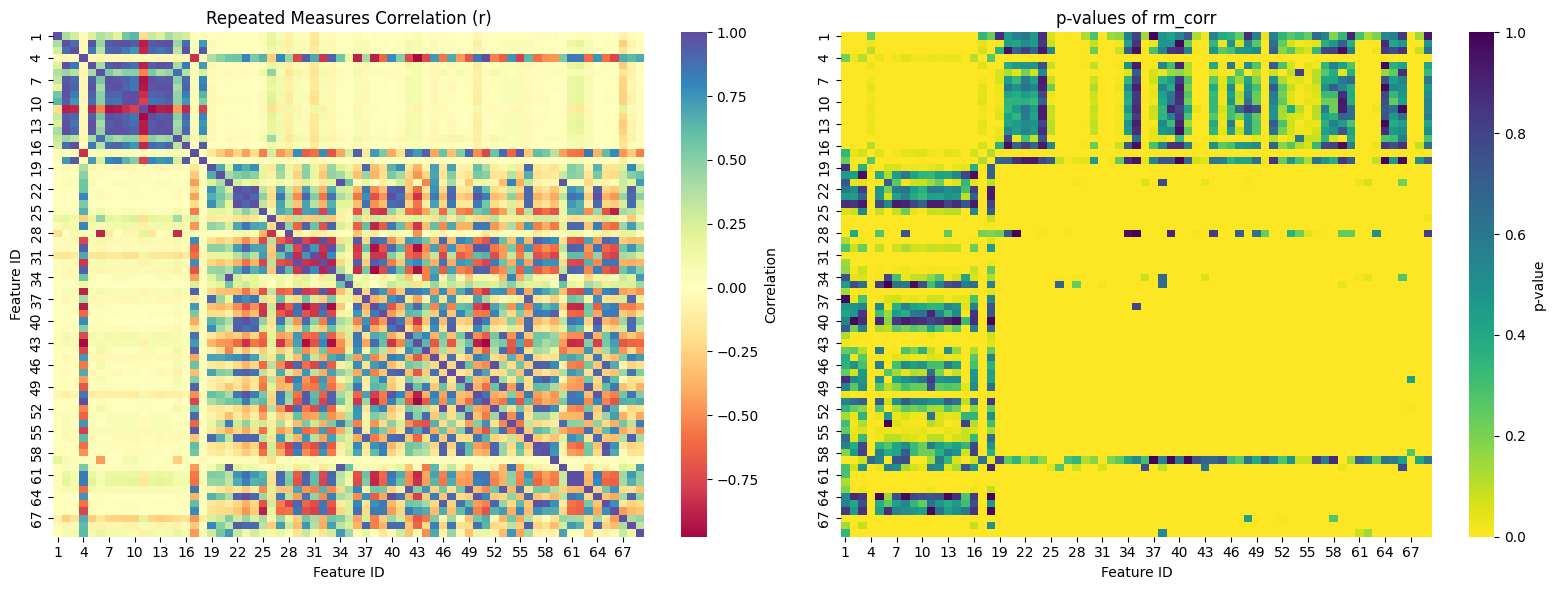

In [45]:


# Subset to selected KW features (add 'PatientName')
df_selected = df_combined[selected_features_kw + ['PatientName']]

# Compute repeated measures correlation
n = len(selected_features_kw)
corr_matrix = np.zeros((n, n))
pval_matrix = np.zeros((n, n))

for i in range(n):
    for j in range(n):
        if i == j:
            corr_matrix[i, j] = 1
            pval_matrix[i, j] = 0
        else:
            res = pg.rm_corr(data=df_selected, x=selected_features_kw[i], y=selected_features_kw[j], subject='PatientName')
            corr_matrix[i, j] = res['r'].values[0]
            pval_matrix[i, j] = res['pval'].values[0]  # <- fixed here


# Convert to labeled DataFrames
corr_df = pd.DataFrame(corr_matrix, index=range(1, n+1), columns=range(1, n+1))
pval_df = pd.DataFrame(pval_matrix, index=range(1, n+1), columns=range(1, n+1))

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(corr_df, ax=axes[0], cmap='Spectral', center=0, cbar_kws={'label': 'Correlation'})
axes[0].set_title("Repeated Measures Correlation (r)")
axes[0].set_xlabel("Feature ID")
axes[0].set_ylabel("Feature ID")

sns.heatmap(pval_df, ax=axes[1], cmap='viridis_r', vmin=0, vmax=1, cbar_kws={'label': 'p-value'})
axes[1].set_title("p-values of rm_corr")
axes[1].set_xlabel("Feature ID")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Load your data (replace with your actual file if needed)
# df_combined = pd.read_csv("df_combined_corrected.csv")

# Define predictors and target
target_col = "Model"
feature_cols = df_combined.drop(columns=["PatientName", "Model", "Wavelength", "GLbins", "Reconstruction"]).select_dtypes("number").columns

# 5-fold CV setup
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Models
models = {
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "SVM": make_pipeline(StandardScaler(), SVC(kernel="rbf", probability=True, random_state=42))
}

# Per-feature scoring
results = []
for i, feature in enumerate(feature_cols, start=1):
    row = {"ID": i, "Feature": feature}
    for name, model in models.items():
        X = df_combined[[feature]]
        y = df_combined[target_col]
        scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")
        row[name] = scores.mean()
    row["Average"] = np.mean([row["Random Forest"], row["Gradient Boosting"], row["SVM"]])
    results.append(row)

# Final table
df_scores = pd.DataFrame(results)
df_scores = df_scores[["ID", "Feature", "Random Forest", "Gradient Boosting", "SVM", "Average"]]
df_scores = df_scores.sort_values("Average", ascending=False).reset_index(drop=True)


# Optionally save to CSV
# df_scores.to_csv("feature_scores_table_ST4.csv", index=False)


   ID                         Feature  Random Forest  Gradient Boosting  \
0   3                       FO Energy            1.0           0.997357   
1  16                  FO TotalEnergy            1.0           0.997357   
2   2                 FO 90Percentile            1.0           1.000000   
3  14              FO RootMeanSquared            1.0           1.000000   
4   9                         FO Mean            1.0           0.998675   
5  10                       FO Median            1.0           0.986775   
6  18                     FO Variance            1.0           0.947537   
7   8        FO MeanAbsoluteDeviation            1.0           0.922842   
8  13  FO RobustMeanAbsoluteDeviation            1.0           0.917114   
9   1                 FO 10Percentile            1.0           0.918867   

        SVM   Average  
0  0.864635  0.953997  
1  0.864635  0.953997  
2  0.782180  0.927393  
3  0.769837  0.923279  
4  0.739858  0.912844  
5  0.738093  0.908289  
6  0.6

In [53]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None):
    display(df_scores)


,ID,Feature,Random Forest,Gradient Boosting,SVM,Average
0,3,FO Energy,1.000000,0.997357,0.864635,0.953997
1,16,FO TotalEnergy,1.000000,0.997357,0.864635,0.953997
2,2,FO 90Percentile,1.000000,1.000000,0.782180,0.927393
3,14,FO RootMeanSquared,1.000000,1.000000,0.769837,0.923279
4,9,FO Mean,1.000000,0.998675,0.739858,0.912844
5,10,FO Median,1.000000,0.986775,0.738093,0.908289
6,18,FO Variance,1.000000,0.947537,0.688266,0.878601
7,8,FO MeanAbsoluteDeviation,1.000000,0.922842,0.708557,0.877133
8,13,FO RobustMeanAbsoluteDeviation,1.000000,0.917114,0.710763,0.875959
9,1,FO 10Percentile,1.000000,0.918867,0.691772,0.870213
